# VAE diagnostics

A compact view of one trained VAE: prior samples, reconstructions, class prototypes, latent-dimension activity, and hole scores.

In [47]:
from pathlib import Path
import math
import re
import sys

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Subset


REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "src"))

from domain_knowledge_analysis import utils
from domain_knowledge_analysis.math.gaussian import gaussian_log_prob
from domain_knowledge_analysis.scoring.signals import HoleScoreEstimator

## Settings

In [48]:
CHECKPOINT = REPO_ROOT / "runs/vae_mnist_lr_0.001_24_jul_1720_B_beta_3/checkpoints/last.pt"
BATCH_SIZE = 256
HOLE_SCORE_SAMPLES = 1000
LEAKAGE_FREE_COMPARISON = True
SEED = 42

## Analysis

In [ ]:
class VaeDiagnostics:
    def __init__(self, checkpoint_path, batch_size=256, hole_score_samples=1000, seed=42, leakage_free=True):
        self.checkpoint_path = Path(checkpoint_path)
        self.batch_size = batch_size
        self.hole_score_samples = hole_score_samples
        self.seed = seed
        self.leakage_free = leakage_free
        self.device = utils.get_device()

        checkpoint = torch.load(self.checkpoint_path, map_location="cpu", weights_only=False)
        self.config = checkpoint["config"]
        self.model = utils.create_model(self.config)
        self.model.load_state_dict(checkpoint["model_state_dict"])
        self.model = self.model.to(self.device).eval()

        run_name = self.checkpoint_path.parents[1].name
        suffix = re.search(r"\d{4}_(.+)$", run_name)
        self.name = suffix.group(1) if suffix else run_name
        self.latent_dim = self.config["model"]["encoder"]["latent_dim"]

        train_loader, validation_loader = utils.create_training_dataloaders(self.config)
        test_dataset = utils.create_dataset(self.config, self.config["dataset"]["name"], train=False)

        self.train_loader = self._loader(train_loader.dataset)
        self.validation_loader = self._loader(validation_loader.dataset)
        self.test_loader = self._loader(test_dataset)

        self.train_mean, self.train_log_variance, self.train_labels = self._encode(self.train_loader)

        self.hole_estimator = HoleScoreEstimator(self.train_loader, self.model, self.config["model"]["name"].lower())
        self.hole_estimator.q_in_mean = self.train_mean.to(self.device)
        self.hole_estimator.q_in_log_variance = self.train_log_variance.to(self.device)

        print(f"{self.name} | {self.config['dataset']['name']} | {self.model.decoder_distribution_name} | {self.latent_dim} latent dimensions | {self.device}")

    def _loader(self, dataset):
        return DataLoader(dataset, batch_size=self.batch_size, shuffle=False, num_workers=0)

    @torch.no_grad()
    def _encode(self, loader):
        means = []
        log_variances = []
        labels = []

        for images, batch_labels in loader:
            mean, log_variance = self.model.encoder(images.to(self.device))
            means.append(mean.cpu())
            log_variances.append(log_variance.cpu())
            labels.append(batch_labels.cpu().flatten())

        return torch.cat(means), torch.cat(log_variances), torch.cat(labels)

    def _images(self, axes, images, titles=None):
        for index, (axis, image) in enumerate(zip(axes.flat, images)):
            axis.imshow(image.squeeze().cpu(), cmap="gray", vmin=0, vmax=1)
            axis.axis("off")

            if titles is not None:
                axis.set_title(titles[index])

    @torch.no_grad()
    def prior_samples(self):
        torch.manual_seed(self.seed)
        images = self.model.generate_images(100).cpu()
        figure, axes = plt.subplots(10, 10, figsize=(10, 10))
        self._images(axes, images)
        figure.suptitle(f"{self.name}: samples from the prior")
        plt.tight_layout()
        plt.show()

    @torch.no_grad()
    def reconstructions(self):
        images = torch.stack([self.test_loader.dataset[index][0] for index in range(10)])
        reconstructions = self.model.reconstruct_images(images).cpu()
        figure, axes = plt.subplots(2, 10, figsize=(15, 3))
        self._images(axes[0], images)
        self._images(axes[1], reconstructions)
        axes[0, 0].set_ylabel("Original")
        axes[1, 0].set_ylabel("Reconstruction")
        figure.suptitle(f"{self.name}: test reconstructions")
        plt.tight_layout()
        plt.show()

    @torch.no_grad()
    def class_prototypes(self):
        class_ids = self.train_labels.unique(sorted=True)
        latents = torch.stack([self.train_mean[self.train_labels == class_id].mean(dim=0) for class_id in class_ids])
        images = self.model.generate_images(len(latents), latents).cpu()
        titles = [str(class_id.item()) for class_id in class_ids]
        figure, axes = plt.subplots(1, len(images), figsize=(15, 2))
        self._images(axes, images, titles)
        figure.suptitle(f"{self.name}: decoded class prototypes")
        plt.tight_layout()
        plt.show()

    def latent_statistics(self):
        active_mean_variance_threshold = 1e-2
        active_kl_threshold = 1e-2

        means = self.train_mean.float()
        log_variances = self.train_log_variance.float()
        posterior_variances = log_variances.exp()

        mean_of_posterior_means = means.mean(dim=0)
        variance_of_posterior_means = means.var(dim=0, unbiased=False)
        mean_posterior_variance = posterior_variances.mean(dim=0)
        aggregate_posterior_variance = variance_of_posterior_means + mean_posterior_variance
        mean_kl_per_dimension = 0.5 * (posterior_variances + means.square() - 1 - log_variances).mean(dim=0)

        active_by_mean_variance = variance_of_posterior_means > active_mean_variance_threshold
        active_by_kl = mean_kl_per_dimension > active_kl_threshold
        pruned = ~(active_by_mean_variance | active_by_kl)

        print(f"{self.name} — {self.model.decoder_distribution_name}")
        print("dim | E[mu]    | Var_x(mu) | E[sigma^2] | Var_q(z) | mean KL  | pruned")
        print("----|----------|-----------|------------|----------|----------|-------")

        for dimension in range(self.latent_dim):
            print(f"{dimension:>3} | {mean_of_posterior_means[dimension].item():>8.4f} | {variance_of_posterior_means[dimension].item():>9.5f} | {mean_posterior_variance[dimension].item():>10.5f} | {aggregate_posterior_variance[dimension].item():>8.5f} | {mean_kl_per_dimension[dimension].item():>8.5f} | {str(bool(pruned[dimension])):>6}")

        pruned_dimensions = torch.where(pruned)[0].tolist()
        print(f"\nPruned dimensions: {len(pruned_dimensions)}/{self.latent_dim} {pruned_dimensions}")

        dimensions = torch.arange(self.latent_dim)
        figure, axes = plt.subplots(2, 2, figsize=(12, 7))

        axes[0, 0].bar(dimensions, mean_of_posterior_means)
        axes[0, 0].set_title("Mean posterior mean")

        axes[0, 1].bar(dimensions, variance_of_posterior_means)
        axes[0, 1].axhline(active_mean_variance_threshold, color="black", linestyle="--")
        axes[0, 1].set_title("Posterior-mean activity")

        axes[1, 0].bar(dimensions, mean_kl_per_dimension)
        axes[1, 0].axhline(active_kl_threshold, color="black", linestyle="--")
        axes[1, 0].set_title("Mean KL")

        axes[1, 1].bar(dimensions, aggregate_posterior_variance, label="aggregate")
        axes[1, 1].bar(dimensions, mean_posterior_variance, label="conditional")
        axes[1, 1].set_title("Posterior variances")
        axes[1, 1].legend()

        for axis in axes.flat:
            axis.set_xlabel("Latent dimension")

        figure.suptitle(f"{self.name}: latent-dimension summary")
        plt.tight_layout()
        plt.show()

    def _query_loader(self, loader, seed):
        count = min(self.hole_score_samples, len(loader.dataset))
        generator = torch.Generator().manual_seed(seed)
        indices = torch.randperm(len(loader.dataset), generator=generator)[:count]
        dataset = Subset(loader.dataset, indices.tolist())
        return self._loader(dataset)

    @torch.no_grad()
    def _scores(self, loader):
        scores = []

        for images, _ in loader:
            mean, log_variance = self.model.encoder(images.to(self.device))
            latents = self.model.reparametrize(mean, log_variance)
            scores.append(self.hole_estimator.estimate_h(latents).cpu())

        return torch.cat(scores)

    def _print_distribution_summary(self, distributions):
        print(f"{'distribution':<30} {'n':>6} {'mean':>12} {'std':>12}")

        for name, values in distributions.items():
            values = torch.as_tensor(values).float()
            print(f"{name:<30} {len(values):>6} {values.mean().item():>12.6f} {values.std(unbiased=True).item():>12.6f}")

    def _plot_distributions(self, distributions, title):
        for name, values in distributions.items():
            plt.hist(values.numpy(), bins=50, density=True, alpha=0.45, label=name)

        plt.xlabel("H(z)")
        plt.ylabel("Density")
        plt.title(title)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def hole_scores(self):
        torch.manual_seed(self.seed)

        scores = {
            "training": self._scores(self._query_loader(self.train_loader, self.seed)),
            "validation": self._scores(self._query_loader(self.validation_loader, self.seed + 1)),
            "test": self._scores(self._query_loader(self.test_loader, self.seed + 2)),
        }

        self._print_distribution_summary(scores)
        self._plot_distributions(scores, f"{self.name}: hole scores using the training aggregate posterior")

    @torch.no_grad()
    def _log_q_leave_one_out(self, latents, component_indices, query_batch_size=64):
        means = self.hole_estimator.q_in_mean
        log_variances = self.hole_estimator.q_in_log_variance

        if len(latents) != len(component_indices):
            raise ValueError("Each latent must identify its generating mixture component.")

        if len(means) < 2:
            raise ValueError("Leave-one-out requires at least two mixture components.")

        inverse_variances = torch.exp(-log_variances)
        log_q_batches = []

        for start in range(0, len(latents), query_batch_size):
            stop = min(start + query_batch_size, len(latents))
            z_batch = latents[start:stop].unsqueeze(1)
            component_log_q = -0.5 * torch.sum(math.log(2.0 * math.pi) + log_variances.unsqueeze(0) + (z_batch - means.unsqueeze(0)).square() * inverse_variances.unsqueeze(0), dim=-1)
            row_indices = torch.arange(stop - start, device=self.device)
            generating_components = component_indices[start:stop].to(self.device)
            component_log_q[row_indices, generating_components] = -torch.inf
            log_q_batch = torch.logsumexp(component_log_q, dim=1) - math.log(len(means) - 1)
            log_q_batches.append(log_q_batch)

        return torch.cat(log_q_batches)

    @torch.no_grad()
    def leakage_comparison(self):
        if not self.leakage_free:
            return

        count = min(self.hole_score_samples, len(self.train_mean))
        index_generator = torch.Generator().manual_seed(self.seed)
        component_indices = torch.randperm(len(self.train_mean), generator=index_generator)[:count]
        means = self.train_mean[component_indices].to(self.device)
        log_variances = self.train_log_variance[component_indices].to(self.device)

        latent_generator = torch.Generator(device="cpu").manual_seed(self.seed + 200)
        noise = torch.randn(means.shape, generator=latent_generator, dtype=means.dtype, device="cpu").to(self.device)
        latents = means + noise * torch.exp(0.5 * log_variances)

        self_included = self.hole_estimator.estimate_h(latents).detach().cpu()
        log_q_leave_one_out = self._log_q_leave_one_out(latents, component_indices, query_batch_size=64)
        log_prior = gaussian_log_prob(latents, torch.zeros_like(latents), torch.zeros_like(latents))
        leave_one_out = (log_prior - log_q_leave_one_out).detach().cpu()

        torch.manual_seed(self.seed + 201)
        held_out = self._scores(self._query_loader(self.validation_loader, self.seed + 1)).detach().cpu()

        distributions = {"self included": self_included, "leave one out": leave_one_out, "held-out validation": held_out}
        self._print_distribution_summary(distributions)
        self._plot_distributions(distributions, f"{self.name}: calibration leakage comparison")

    @torch.no_grad()
    def posterior_noise_reconstructions(self, sigma_scales=(0.0, 1.0, 1.5, 2.0, 3.0), n_images=10):
        images = torch.stack([self.test_loader.dataset[index][0] for index in range(n_images)])
        images_on_device = images.to(self.device)
        mean, log_variance = self.model.encoder(images_on_device)
        standard_deviation = torch.exp(0.5 * log_variance)

        generator = torch.Generator(device="cpu").manual_seed(self.seed)
        noise = torch.randn(mean.shape, generator=generator, device="cpu").to(self.device)

        reconstructions = []
        for sigma_scale in sigma_scales:
            latents = mean + sigma_scale * standard_deviation * noise
            logits = self.model.decoder(latents)
            reconstruction = self.model.decoder_distribution(logits, self.model.decoder_distribution_name)
            reconstructions.append(reconstruction.cpu())

        figure, axes = plt.subplots(len(sigma_scales) + 1, n_images, figsize=(15, 1.8 * (len(sigma_scales) + 1)))
        self._images(axes[0], images)
        axes[0, 0].set_ylabel("Original")

        for row, (sigma_scale, reconstruction) in enumerate(zip(sigma_scales, reconstructions), start=1):
            self._images(axes[row], reconstruction)
            axes[row, 0].set_ylabel(f"{sigma_scale:g}σ")

        figure.suptitle(f"{self.name}: reconstruction sensitivity to posterior noise")
        plt.tight_layout()
        plt.show()

    @torch.no_grad()
    def posterior_noise_reconstruction_nll(self, sigma_scales=(0.0, 1.0, 1.5, 2.0, 3.0), n_latent_samples=10, max_images=1000):
        if n_latent_samples < 1:
            raise ValueError("n_latent_samples must be at least one.")

        log_prob_function = utils.create_loss(self.config).log_prob_function
        losses = {sigma_scale: [] for sigma_scale in sigma_scales}
        images_seen = 0
        torch.manual_seed(self.seed)

        for images, _ in self.test_loader:
            if images_seen >= max_images:
                break

            images = images[:max_images - images_seen].to(self.device)
            mean, log_variance = self.model.encoder(images)
            standard_deviation = torch.exp(0.5 * log_variance)
            batch_losses = {sigma_scale: torch.zeros(len(images), device=self.device) for sigma_scale in sigma_scales}

            for _ in range(n_latent_samples):
                noise = torch.randn_like(standard_deviation)

                for sigma_scale in sigma_scales:
                    latents = mean + sigma_scale * standard_deviation * noise
                    logits = self.model.decoder(latents)
                    batch_losses[sigma_scale] += -log_prob_function(images, logits) / n_latent_samples

            for sigma_scale in sigma_scales:
                losses[sigma_scale].append(batch_losses[sigma_scale].cpu())

            images_seen += len(images)

        losses = {sigma_scale: torch.cat(values) for sigma_scale, values in losses.items()}
        baseline = losses[sigma_scales[0]].mean()

        print(f"{self.name} — expected reconstruction NLL over {images_seen} test images")
        print(f"{'noise scale':>11} | {'mean NLL':>12} | {'change':>12}")
        print("------------|--------------|-------------")

        for sigma_scale, values in losses.items():
            mean_loss = values.mean()
            print(f"{sigma_scale:>10g}σ | {mean_loss.item():>12.4f} | {(mean_loss - baseline).item():>12.4f}")

        means = [values.mean().item() for values in losses.values()]
        plt.plot(sigma_scales, means, marker="o")
        plt.xlabel("Posterior noise scale")
        plt.ylabel("Mean reconstruction NLL")
        plt.title(f"{self.name}: reconstruction cost of posterior noise")
        plt.tight_layout()
        plt.show()

        return losses

    @torch.no_grad()
    def posterior_noise_objective(self, reconstruction_losses, beta=None):
        sigma_scales = tuple(reconstruction_losses.keys())

        if 1.0 not in sigma_scales:
            raise ValueError("The reconstruction losses must include the trained posterior scale 1.0σ.")

        number_of_images = len(reconstruction_losses[1.0])
        if any(len(values) != number_of_images for values in reconstruction_losses.values()):
            raise ValueError("Every noise scale must contain the same number of reconstruction losses.")

        if beta is None:
            #beta = float(self.config["loss"]["beta"])
            beta = 3.0

        rates = {sigma_scale: [] for sigma_scale in sigma_scales if sigma_scale > 0}
        images_seen = 0

        for images, _ in self.test_loader:
            if images_seen >= number_of_images:
                break

            images = images[:number_of_images - images_seen].to(self.device)
            mean, log_variance = self.model.encoder(images)
            variance = log_variance.exp()

            for sigma_scale in rates:
                scaled_variance = sigma_scale**2 * variance
                scaled_log_variance = log_variance + 2.0 * math.log(sigma_scale)
                kl = 0.5 * (mean.square() + scaled_variance - scaled_log_variance - 1.0).sum(dim=1)
                rates[sigma_scale].append(kl.cpu())

            images_seen += len(images)

        rates = {sigma_scale: torch.cat(values) for sigma_scale, values in rates.items()}
        rates[0.0] = torch.full((number_of_images,), torch.inf)
        rates = {sigma_scale: rates[sigma_scale] for sigma_scale in sigma_scales}

        objectives = {
            sigma_scale: reconstruction_losses[sigma_scale] + beta * rates[sigma_scale]
            for sigma_scale in sigma_scales
        }

        baseline_reconstruction = reconstruction_losses[1.0].mean()
        baseline_rate = rates[1.0].mean()
        beta_critical = {}

        for sigma_scale in sigma_scales:
            reconstruction_increase = reconstruction_losses[sigma_scale].mean() - baseline_reconstruction
            rate_reduction = baseline_rate - rates[sigma_scale].mean()

            if sigma_scale != 1.0 and torch.isfinite(rate_reduction) and rate_reduction > 0:
                beta_critical[sigma_scale] = (reconstruction_increase / rate_reduction).item()
            else:
                beta_critical[sigma_scale] = math.nan

        print(f"{self.name} — posterior-noise objective over {number_of_images} test images, β={beta:g}")
        print(f"{'scale':>7} | {'D(c)':>12} | {'R(c)':>10} | {'βR(c)':>12} | {'Lβ(c)':>12} | {'β critical':>12}")
        print("--------|--------------|------------|--------------|--------------|-------------")

        for sigma_scale in sigma_scales:
            reconstruction = reconstruction_losses[sigma_scale].mean().item()
            rate = rates[sigma_scale].mean().item()
            objective = objectives[sigma_scale].mean().item()
            critical = beta_critical[sigma_scale]
            critical_text = f"{critical:.4f}" if math.isfinite(critical) else "n/a"
            print(f"{sigma_scale:>6g}σ | {reconstruction:>12.4f} | {rate:>10.4f} | {beta * rate:>12.4f} | {objective:>12.4f} | {critical_text:>12}")

        positive_scales = [sigma_scale for sigma_scale in sigma_scales if sigma_scale > 0]
        reconstruction_changes = [(reconstruction_losses[sigma_scale].mean() - baseline_reconstruction).item() for sigma_scale in positive_scales]
        weighted_rate_changes = [beta * (rates[sigma_scale].mean() - baseline_rate).item() for sigma_scale in positive_scales]
        objective_changes = [reconstruction_change + rate_change for reconstruction_change, rate_change in zip(reconstruction_changes, weighted_rate_changes)]

        figure, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(positive_scales, reconstruction_changes, marker="o", label="ΔD")
        axes[0].plot(positive_scales, weighted_rate_changes, marker="o", label="βΔR")
        axes[0].plot(positive_scales, objective_changes, marker="o", label="ΔLβ")
        axes[0].axhline(0, color="black", linewidth=1)
        axes[0].set_xlabel("Posterior noise scale")
        axes[0].set_ylabel("Change from 1σ (nats per image)")
        axes[0].set_title("Objective components")
        axes[0].legend()

        critical_scales = [sigma_scale for sigma_scale in positive_scales if math.isfinite(beta_critical[sigma_scale])]
        critical_values = [beta_critical[sigma_scale] for sigma_scale in critical_scales]
        axes[1].plot(critical_scales, critical_values, marker="o")
        axes[1].axhline(beta, color="black", linestyle="--", label=f"current β={beta:g}")
        axes[1].set_xlabel("Posterior noise scale")
        axes[1].set_ylabel("β critical")
        axes[1].set_title("β needed to prefer the scaled posterior")
        axes[1].legend()

        figure.suptitle(f"{self.name}: posterior-noise rate–distortion test")
        plt.tight_layout()
        plt.show()

        return {
            "reconstruction_nll": reconstruction_losses,
            "rate": rates,
            "objective": objectives,
            "beta_critical": beta_critical,
        }

In [50]:
diagnostics = VaeDiagnostics(
    CHECKPOINT,
    batch_size=BATCH_SIZE,
    hole_score_samples=HOLE_SCORE_SAMPLES,
    seed=SEED,
    leakage_free=LEAKAGE_FREE_COMPARISON,
)

B_beta_3 | mnist | bernoulli | 16 latent dimensions | mps


## Prior samples

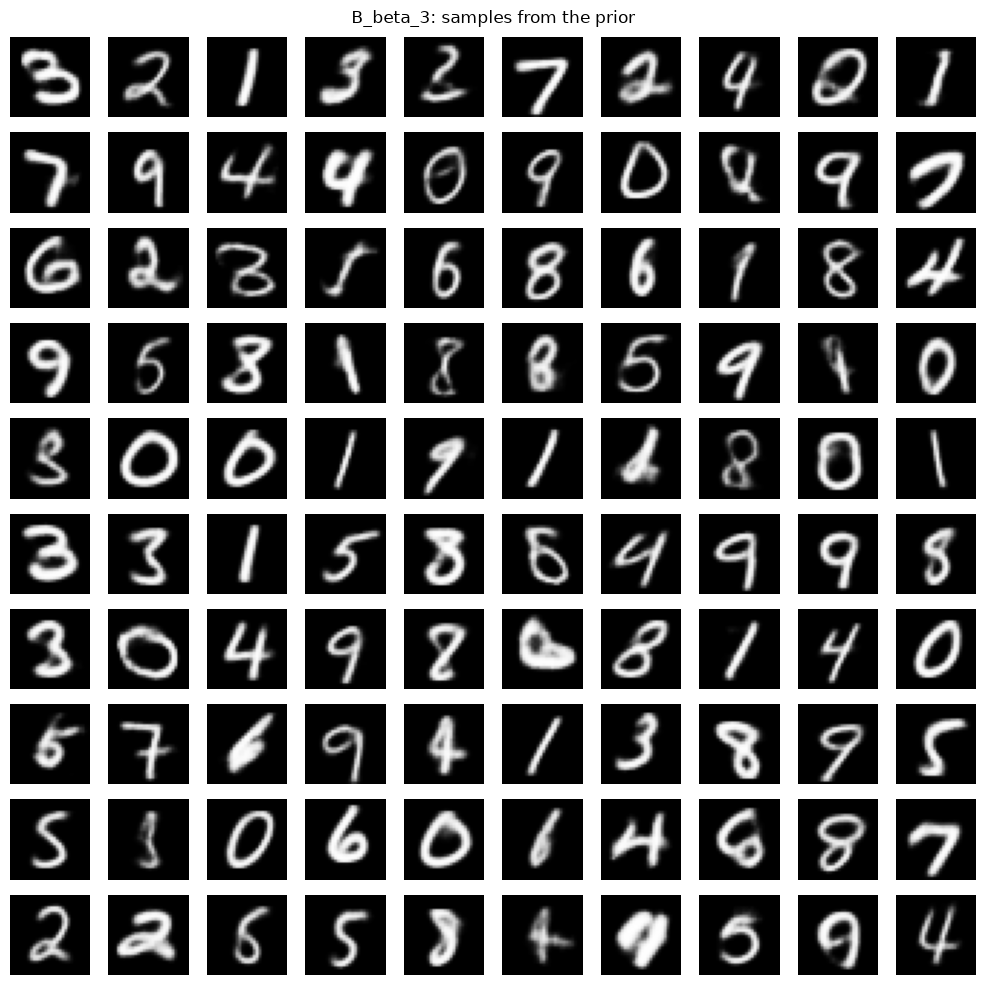

In [51]:
diagnostics.prior_samples()

## Test reconstructions

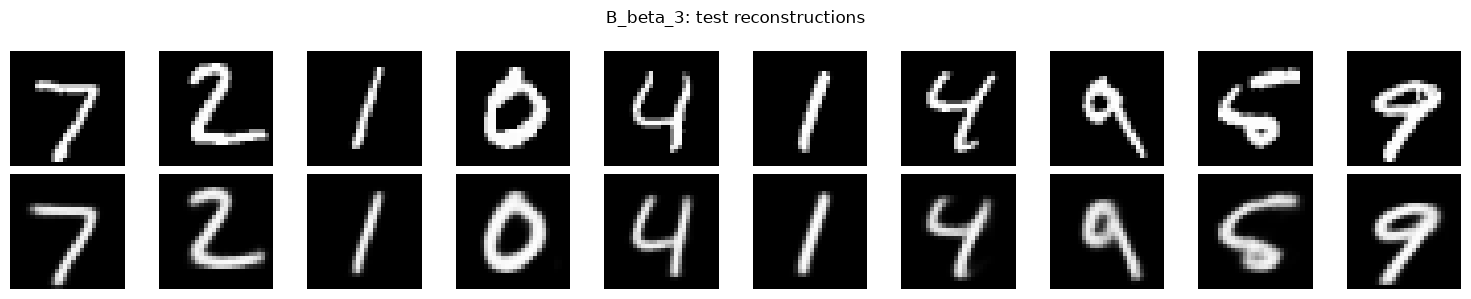

In [52]:
diagnostics.reconstructions()

## Decoded class prototypes

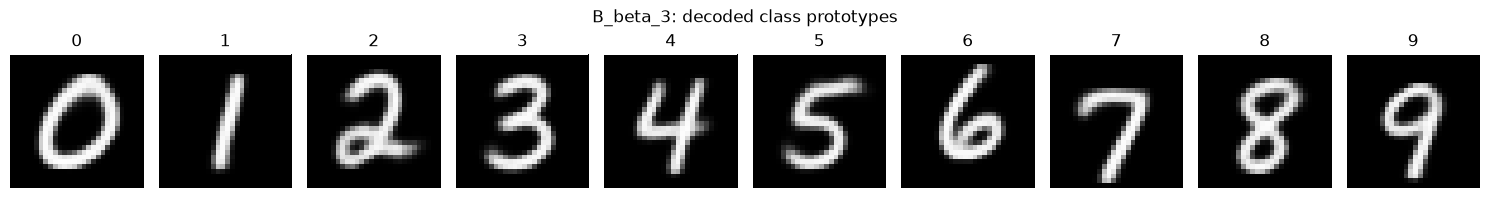

In [53]:
diagnostics.class_prototypes()

## Latent dimensions

B_beta_3 — bernoulli
dim | E[mu]    | Var_x(mu) | E[sigma^2] | Var_q(z) | mean KL  | pruned
----|----------|-----------|------------|----------|----------|-------
  0 |   0.0031 |   0.00010 |    0.99769 |  0.99779 |  0.00006 |   True
  1 |  -0.0030 |   0.00011 |    0.99799 |  0.99811 |  0.00006 |   True
  2 |  -0.0018 |   0.76990 |    0.21942 |  0.98932 |  0.96263 |  False
  3 |   0.0011 |   0.99449 |    0.01337 |  1.00786 |  2.22233 |  False
  4 |  -0.0053 |   0.22227 |    0.77373 |  0.99600 |  0.14343 |  False
  5 |   0.0035 |   0.97989 |    0.01987 |  0.99976 |  2.00847 |  False
  6 |   0.0002 |   0.00011 |    0.99973 |  0.99984 |  0.00006 |   True
  7 |   0.0240 |   0.84232 |    0.15242 |  0.99474 |  0.97317 |  False
  8 |   0.0018 |   0.74337 |    0.25493 |  0.99830 |  0.93232 |  False
  9 |   0.0038 |   0.87718 |    0.11924 |  0.99642 |  1.39273 |  False
 10 |   0.0008 |   0.12515 |    0.87073 |  0.99589 |  0.07885 |  False
 11 |   0.0148 |   0.55164 |    0.43993 |  0.99157 |  0.

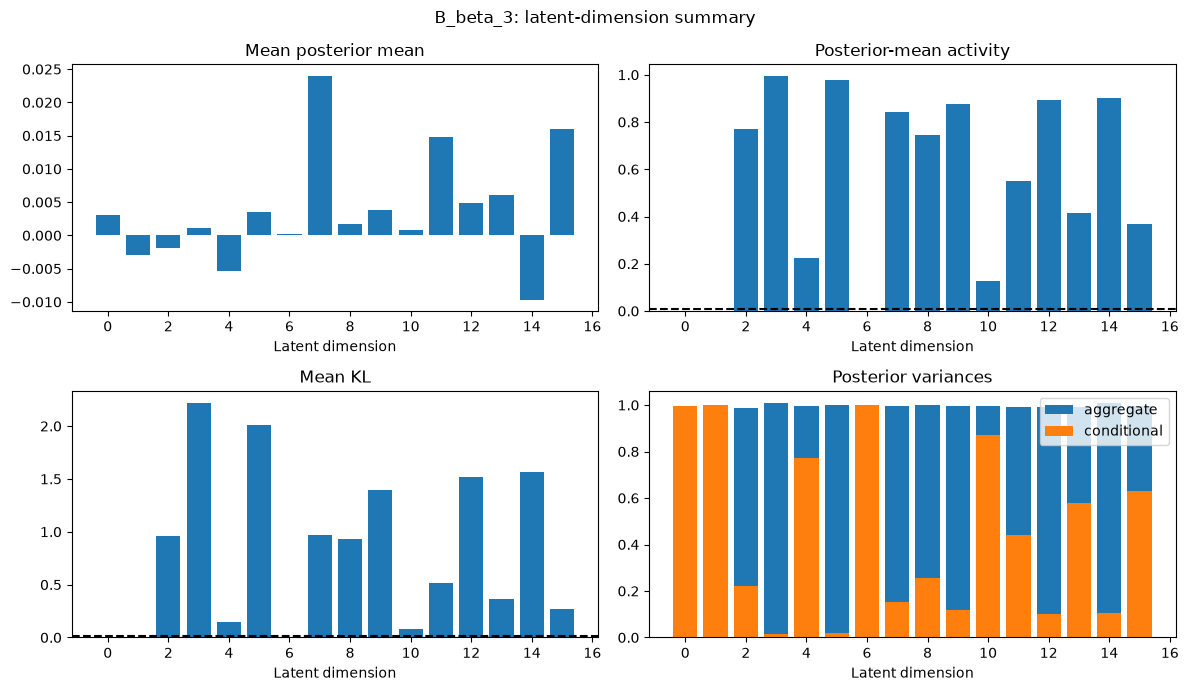

In [54]:
diagnostics.latent_statistics()

## Hole scores

distribution                        n         mean          std
training                         1000    -3.140683     2.893831
validation                       1000     1.753874     3.772947
test                             1000     1.593229     3.604066


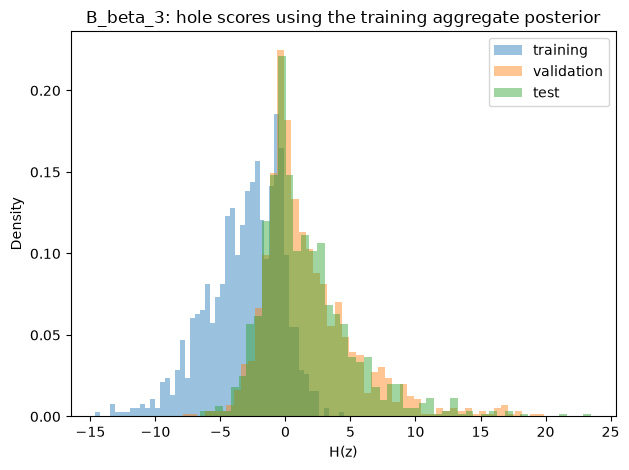

In [55]:
diagnostics.hole_scores()

## Calibration leakage

distribution                        n         mean          std
self included                    1000    -3.101372     2.794903
leave one out                    1000     1.642591     3.845251
held-out validation              1000     1.690852     3.766200


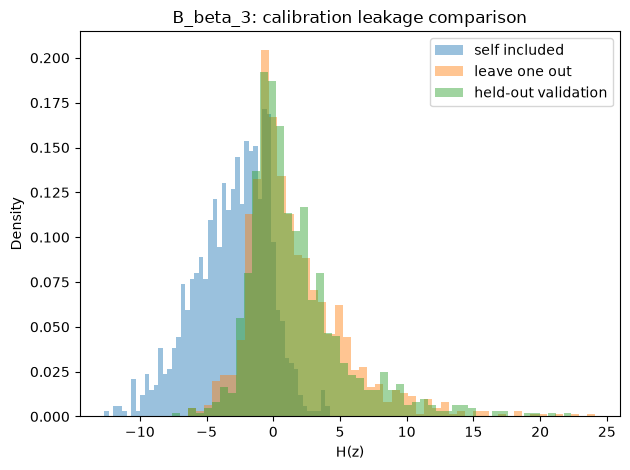

In [56]:
diagnostics.leakage_comparison()

## Posterior noise sensitivity

The `0σ` row decodes each posterior mean. The other rows sample at increasing multiples of the encoder's posterior standard deviation, using the same noise direction at every scale.

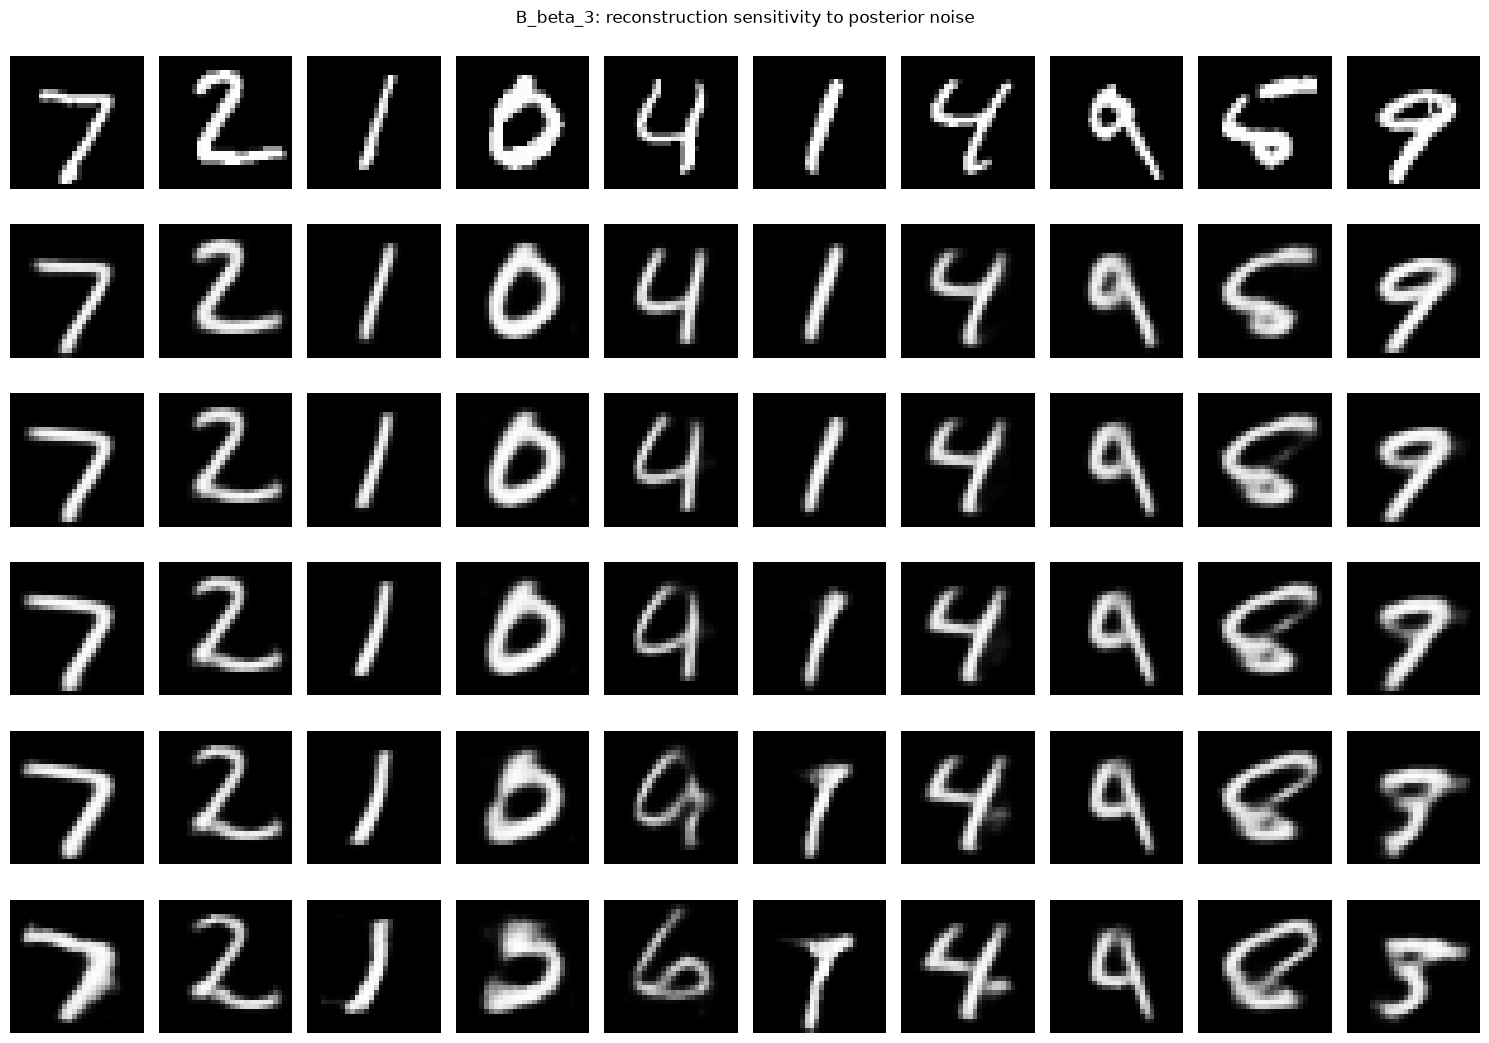

In [57]:
SIGMA_SCALES = (0.0, 1.0, 1.5, 2.0, 3.0)
diagnostics.posterior_noise_reconstructions(SIGMA_SCALES)

B_beta_3 — expected reconstruction NLL over 1000 test images
noise scale |     mean NLL |       change
------------|--------------|-------------
         0σ |      72.4266 |       0.0000
         1σ |      84.7646 |      12.3380
       1.5σ |     100.9488 |      28.5223
         2σ |     123.6820 |      51.2555
         3σ |     181.0447 |     108.6182


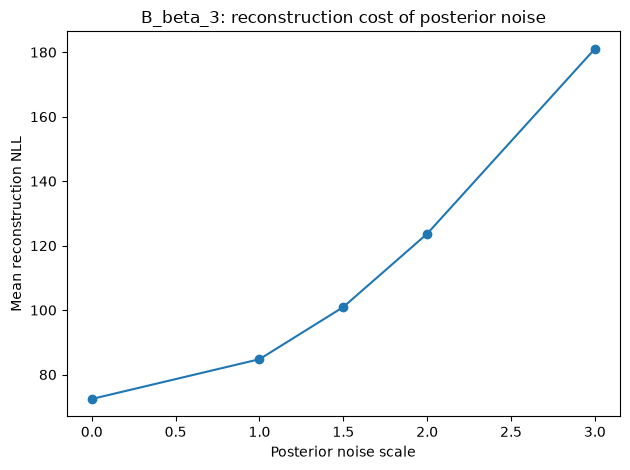

In [58]:
posterior_noise_losses = diagnostics.posterior_noise_reconstruction_nll(
    SIGMA_SCALES,
    n_latent_samples=10,
    max_images=1000,
)

### Full β-objective under scaled posterior noise

This combines reconstruction NLL `D(c)` with the exact Gaussian rate `R(c)` after multiplying every posterior standard deviation by `c`. The trained posterior is `1σ`. At `0σ` the Gaussian is degenerate, so its KL and full objective are infinite.

In [59]:
posterior_noise_objective = diagnostics.posterior_noise_objective(
    posterior_noise_losses,
)

KeyError: 'beta'